<a href="https://colab.research.google.com/github/RiderTheSpeedLover/Jio_Institute/blob/Image-Analysis/ImageAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install opencv-python numpy deepface


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=6dc4f963f5972afc6571696dc58649290f5649040a93e667ff8916ebeaea2dbc
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


Detected Emotion: happy
Face Proportion in Image: 1.07%


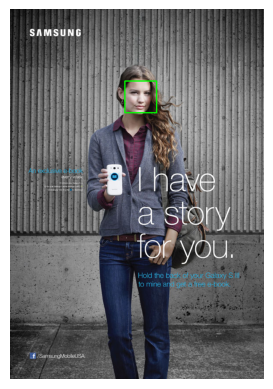

In [3]:
import cv2
import numpy as np
from deepface import DeepFace

# Load image
image_path = "/content/Samsung poster.jpg"  # Change this to your image path
image = cv2.imread(image_path)

# Load OpenCV face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Convert image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

# Get image dimensions
img_height, img_width = image.shape[:2]

# Analyze each face
for (x, y, w, h) in faces:
    # Draw rectangle around the face
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)

    # Calculate face size proportion
    face_area = w * h
    image_area = img_width * img_height
    face_proportion = face_area / image_area

    # Crop face region for emotion detection
    face_crop = image[y:y+h, x:x+w]

    # Save cropped face as temp file
    face_temp_path = "temp_face.jpg"
    cv2.imwrite(face_temp_path, face_crop)

    # Analyze emotion using DeepFace
    analysis = DeepFace.analyze(face_temp_path, actions=['emotion'], enforce_detection=False)
    emotion = analysis[0]['dominant_emotion']

    print(f"Detected Emotion: {emotion}")
    print(f"Face Proportion in Image: {face_proportion:.2%}")

# Display the image with face rectangle
import matplotlib.pyplot as plt

# Convert image from BGR (OpenCV format) to RGB (Matplotlib format)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.axis("off")  # Hide axis
plt.show()

